# Comprehensive Stress Testing for a Multi-Asset ETF Portfolio

This notebook walks through advanced stress-testing techniques using **pyvallocation**.
We answer practical portfolio questions such as:

- *What if equity spreads widen and then mean revert?*
- *What if the 2020 COVID crash repeats?*
- *What is the 95th-percentile max drawdown at 3-month vs 1-year horizon?*
- *What if correlations break down (SPY-TLT hedge fails)?*
- *How does the portfolio perform under bearish equity + rising rates?*

**Assets**: SPY (US equity), TLT (long-term bonds), GLD (gold), DBC (commodities).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pyvallocation import (
    PortfolioWrapper, FlexibleViewsProcessor,
    stress_test, linear_map, kernel_focus_stress,
    entropy_pooling_stress,
    horizon_report, drawdown_quantile,
    simulate_paths, performance_report,
)
np.random.seed(42)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True})

In [2]:
# --- Load ETF prices and compute weekly log returns ---
_paths = [Path(d + "examples/ETF_prices.csv")
          for d in ["", "../", "../../", "../../../"]]
_csv = next((p for p in _paths if p.exists()), None)
if _csv is None:
    raise FileNotFoundError("ETF_prices.csv not found")
prices = pd.read_csv(_csv, index_col="Date", parse_dates=True)
weekly = prices.dropna(how="all").ffill().resample("W-FRI").last()
log_returns = np.log(weekly).diff().dropna(how="all").dropna()
ASSETS = list(log_returns.columns)
print(f"Assets: {ASSETS}  |  Weeks: {len(log_returns)}")
log_returns.tail(3)

Assets: ['DBC', 'GLD', 'SPY', 'TLT']  |  Weeks: 1006


,DBC,GLD,SPY,TLT
Date,,,,
2025-05-09,0.017192,0.029300,-0.004279,-0.007781
2025-05-16,0.003309,-0.041931,0.051559,-0.008653
2025-05-23,0.010329,0.051370,-0.025724,-0.020487


In [3]:
# --- Build a tangency portfolio from the MV frontier ---
wrapper = PortfolioWrapper.from_moments(
    log_returns.mean(), log_returns.cov()
)
frontier = wrapper.variance_frontier(num_portfolios=25)
w_tangency, ret_t, risk_t = frontier.tangency(risk_free_rate=0.0)
print("Tangency weights:")
print(w_tangency.round(4))
print(f"\nExpected return: {ret_t:.4f}  |  Risk: {risk_t:.4f}")

Tangency weights:
DBC    0.0000
GLD    0.3335
SPY    0.4032
TLT    0.2633
Name: Tangency Portfolio (rf=0.00%), dtype: float64

Expected return: 0.0015  |  Risk: 0.0138


---
## Section 1 -- Nominal Performance at Multiple Horizons

We project the tangency portfolio across 1-month, 3-month, 6-month, and
1-year horizons using bootstrapped scenarios and measure VaR/CVaR scaling.

In [4]:
# --- Multi-horizon risk report ---
w_arr = w_tangency.values
hr_nominal = horizon_report(
    w_arr, log_returns.values,
    horizons=[4, 13, 26, 52],
    n_simulations=5000, confidence=0.95, seed=42,
)
print("Nominal horizon report:")
hr_nominal.round(4)

Nominal horizon report:


,mean,stdev,VaR95,CVaR95,ENS
1m,0.0074,0.0284,0.0381,0.0546,5000.0
3m,0.0230,0.0512,0.0605,0.0865,5000.0
6m,0.0470,0.0752,0.0724,0.1014,5000.0
1y,0.0958,0.1101,0.0737,0.1158,5000.0


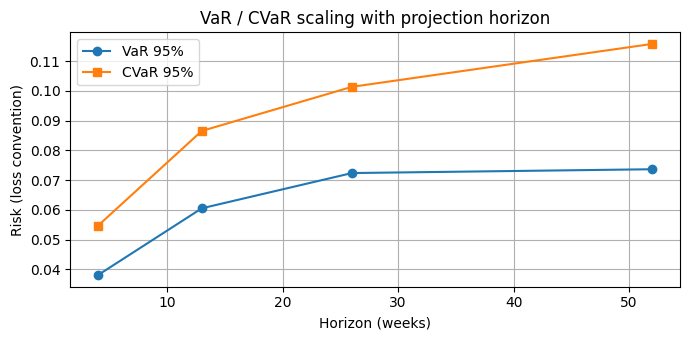

In [5]:
# --- Line chart: VaR / CVaR scaling with horizon ---
fig, ax = plt.subplots(figsize=(7, 3.5))
horizons_weeks = [4, 13, 26, 52]
ax.plot(horizons_weeks, hr_nominal["VaR95"].values,
        "o-", label="VaR 95%")
ax.plot(horizons_weeks, hr_nominal["CVaR95"].values,
        "s-", label="CVaR 95%")
ax.set_xlabel("Horizon (weeks)")
ax.set_ylabel("Risk (loss convention)")
ax.set_title("VaR / CVaR scaling with projection horizon")
ax.legend()
plt.tight_layout(); plt.show()

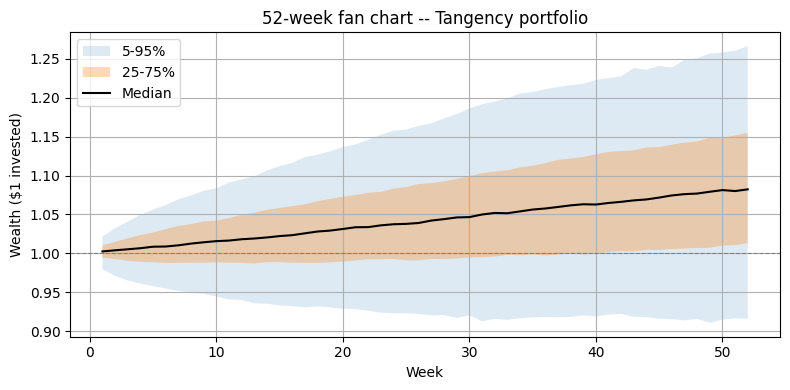

In [6]:
# --- Fan chart: percentile wealth bands over 52 weeks ---
paths = simulate_paths(
    log_returns.values, horizon=52, n_paths=2000, seed=42,
)
port_cum = np.exp((paths @ w_arr))  # cumulative wealth
pcts = np.percentile(port_cum, [5, 25, 50, 75, 95], axis=0)
fig, ax = plt.subplots(figsize=(8, 4))
weeks = np.arange(1, 53)
ax.fill_between(weeks, pcts[0], pcts[4], alpha=0.15, label="5-95%")
ax.fill_between(weeks, pcts[1], pcts[3], alpha=0.30, label="25-75%")
ax.plot(weeks, pcts[2], "k-", lw=1.5, label="Median")
ax.axhline(1, ls="--", color="grey", lw=0.8)
ax.set(xlabel="Week", ylabel="Wealth ($1 invested)",
       title="52-week fan chart -- Tangency portfolio")
ax.legend(); plt.tight_layout(); plt.show()

---
## Section 2 -- Historical Scenario Replay (COVID-Style Crisis)

We locate the worst 13-week drawdown window for SPY in the dataset and
replay those returns through the portfolio using `kernel_focus_stress`
targeting the highest-volatility regime.

In [7]:
# --- Identify worst 13-week window for SPY ---
spy_cum = log_returns["SPY"].cumsum()
rolling_13w = spy_cum - spy_cum.shift(13)
worst_end = rolling_13w.idxmin()
worst_start = spy_cum.index[
    spy_cum.index.get_loc(worst_end) - 13
]
crisis_returns = log_returns.loc[worst_start:worst_end]
print(f"Worst 13-week window: {worst_start.date()} to "
      f"{worst_end.date()}")
print(f"SPY cumulative log-return: "
      f"{crisis_returns['SPY'].sum():.4f}")

Worst 13-week window: 2008-08-22 to 2008-11-21
SPY cumulative log-return: -0.4871


In [8]:
# --- Kernel-focus stress targeting high-vol regime ---
spy_vol = log_returns["SPY"].rolling(13).std().bfill()
df_kernel = kernel_focus_stress(
    w_arr, log_returns.values,
    focus_series=spy_vol.values,
    target=spy_vol.values.max(),
    confidence=0.95,
)
print("Kernel-focus stress (high SPY vol):")
df_kernel.round(4)

Kernel-focus stress (high SPY vol):


,return_nom,stdev_nom,VaR95_nom,CVaR95_nom,ENS_nom,return_stress,stdev_stress,VaR95_stress,CVaR95_stress,ENS_stress,KL_q_p
portfolio_0,0.0015,0.0138,0.0202,0.0313,1006.0,0.0216,0.0265,0.0223,0.0223,6.0834,5.1082


In [9]:
# --- Compare nominal vs crisis-replay single-period ---
nom_report = performance_report(
    w_arr, log_returns.values, confidence=0.95
)
crisis_report = performance_report(
    w_arr, crisis_returns.values, confidence=0.95
)
compare = pd.DataFrame(
    {"Nominal": nom_report, "Crisis window": crisis_report}
)
print("Nominal vs crisis-window performance:")
compare.round(4)

Nominal vs crisis-window performance:


,Nominal,Crisis window
mean,0.0015,-0.0116
stdev,0.0138,0.0313
VaR95,0.0202,0.0903
CVaR95,0.0313,0.0903
ENS,1006.0000,14.0000


---
## Section 3 -- What-If Scenarios via Flexible Views

We use entropy pooling to tilt the probability distribution and answer:

1. **Bearish equity**: SPY expected return <= -0.5% per week, vol doubles.
2. **Rising rates / TLT drop**: TLT expected return <= -0.3% per week.
3. **Correlation breakdown**: SPY-TLT correlation >= +0.3 (hedge fails).

In [10]:
# --- Bearish equity view ---
fv_bear = FlexibleViewsProcessor(
    prior_risk_drivers=log_returns,
    mean_views={"SPY": ("<=", -0.005)},
    vol_views={"SPY": (">=", 0.04)},
    sequential=True,
)
q_bear = fv_bear.get_posterior_probabilities().ravel()
q_bear = q_bear / q_bear.sum()
print(f"Bearish equity: ENS = "
      f"{1.0 / (q_bear ** 2).sum():.1f}")

Bearish equity: ENS = 758.2


In [11]:
# --- Rising rates / TLT drop view ---
fv_rates = FlexibleViewsProcessor(
    prior_risk_drivers=log_returns,
    mean_views={"TLT": ("<=", -0.003)},
    sequential=True,
)
q_rates = fv_rates.get_posterior_probabilities().ravel()
q_rates = q_rates / q_rates.sum()
print(f"Rising rates: ENS = "
      f"{1.0 / (q_rates ** 2).sum():.1f}")

Rising rates: ENS = 974.0


In [12]:
# --- Correlation breakdown: SPY-TLT hedge fails ---
fv_corr = FlexibleViewsProcessor(
    prior_risk_drivers=log_returns,
    corr_views={("SPY", "TLT"): (">=", 0.3)},
    sequential=True,
)
q_corr = fv_corr.get_posterior_probabilities().ravel()
q_corr = q_corr / q_corr.sum()
print(f"Correlation breakdown: ENS = "
      f"{1.0 / (q_corr ** 2).sum():.1f}")

Correlation breakdown: ENS = 760.0


In [13]:
# --- Build scenario dict for reuse ---
scenarios = {
    "Nominal": None, "Bearish equity": q_bear,
    "Rising rates": q_rates, "Corr breakdown": q_corr,
}
rows = []
for name, q in scenarios.items():
    hr = horizon_report(
        w_arr, log_returns.values,
        horizons=[13, 52], n_simulations=5000,
        p=q, confidence=0.95, seed=42)
    for h_label in hr.index:
        row = hr.loc[h_label].to_dict()
        row.update({"scenario": name, "horizon": h_label})
        rows.append(row)

In [14]:
# --- Display stress comparison table ---
stress_table = pd.DataFrame(rows).set_index(
    ["scenario", "horizon"]
)
print("Stress comparison (3m & 1y horizons):")
stress_table[["mean", "CVaR95"]].round(4)

Stress comparison (3m & 1y horizons):


mean  CVaR95
scenario       horizon                
Nominal        3m       0.0232  0.0830
               1y       0.0960  0.1183
Bearish equity 3m      -0.0214  0.1559
               1y      -0.0700  0.2776
Rising rates   3m       0.0131  0.0979
               1y       0.0633  0.1505
Corr breakdown 3m       0.0122  0.1459
               1y       0.0528  0.2404

---
## Section 4 -- Combined Stress + Mean Reversion

**Question**: *What if SPY drops ~15% then mean reverts over 6 months?*

We model this as a two-phase simulation:
1. **Shock phase** (13 weeks): amplified returns with a negative shift.
2. **Recovery phase** (13 weeks): nominal returns.

In [15]:
# --- Shock phase: 13 weeks of stressed returns ---
# Column order: DBC, GLD, SPY, TLT -> shift SPY (index 2)
shock_transform = linear_map(
    scale=2.0,
    mean_shift=np.array([0.0, 0.0, -0.005, 0.0]),
)
shocked_returns = shock_transform(log_returns.values)
paths_shock = simulate_paths(
    shocked_returns, horizon=13, n_paths=2000, seed=42,
)
paths_recov = simulate_paths(
    log_returns.values, horizon=13, n_paths=2000, seed=43,
)
print(f"Shock paths shape:    {paths_shock.shape}")
print(f"Recovery paths shape: {paths_recov.shape}")

Shock paths shape:    (2000, 13, 4)
Recovery paths shape: (2000, 13, 4)


In [16]:
# --- Stitch shock + recovery into 26-week paths ---
# Cumulative returns: recovery starts from shock endpoint
offset = paths_shock[:, -1:, :]  # (2000, 1, 4)
paths_recov_shifted = paths_recov + offset
paths_full = np.concatenate(
    [paths_shock, paths_recov_shifted], axis=1
)
port_wealth = np.exp(paths_full @ w_arr)
print(f"Combined paths shape: {paths_full.shape}")
print(f"Median terminal wealth: "
      f"{np.median(port_wealth[:, -1]):.4f}")

Combined paths shape: (2000, 26, 4)
Median terminal wealth: 1.0383


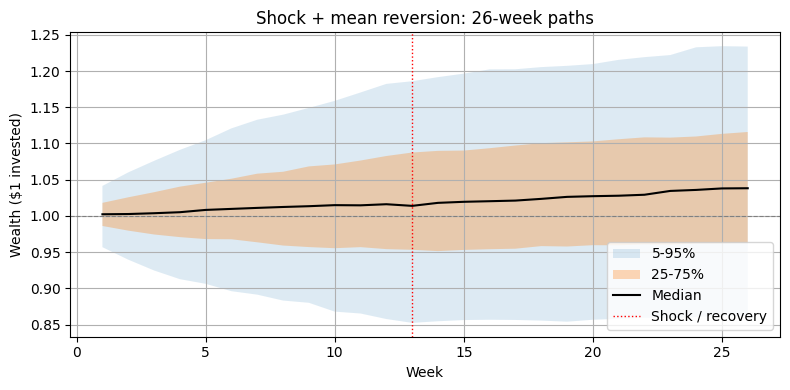

In [17]:
# --- Two-phase fan chart ---
pcts = np.percentile(port_wealth, [5, 25, 50, 75, 95], axis=0)
weeks = np.arange(1, 27)
fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(weeks, pcts[0], pcts[4], alpha=0.15, label="5-95%")
ax.fill_between(weeks, pcts[1], pcts[3], alpha=0.30, label="25-75%")
ax.plot(weeks, pcts[2], "k-", lw=1.5, label="Median")
ax.axhline(1, ls="--", color="grey", lw=0.8)
ax.axvline(13, ls=":", color="red", lw=1, label="Shock / recovery")
ax.set(xlabel="Week", ylabel="Wealth ($1 invested)",
       title="Shock + mean reversion: 26-week paths")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

---
## Section 5 -- Multi-Horizon Drawdown Analysis

We compute the maximum-drawdown distribution at multiple horizons under
both nominal and bearish-equity stress, answering:
*What is the 95th-percentile max drawdown at 3 months vs 1 year?*

In [18]:
# --- Nominal drawdown quantiles ---
dd_horizons = [4, 13, 26, 52]
dd_nom = {}
for h in dd_horizons:
    dd_nom[h] = drawdown_quantile(
        w_arr, log_returns.values,
        horizon=h, confidence=0.95,
        n_paths=2000, seed=42,
    )
dd_nom_df = pd.DataFrame(dd_nom).T
dd_nom_df.index.name = "horizon_weeks"
print("Nominal max-drawdown distribution:")
dd_nom_df.round(4)

Nominal max-drawdown distribution:


,max_dd_mean,max_dd_median,max_dd_95,max_dd_worst
horizon_weeks,,,,
4,0.0125,0.0087,0.0385,0.1185
13,0.0340,0.0286,0.0809,0.1538
26,0.0522,0.0447,0.1100,0.2618
52,0.0747,0.0659,0.1475,0.2794


In [19]:
# --- Stressed drawdown quantiles (bearish equity) ---
dd_stress = {}
for h in dd_horizons:
    dd_stress[h] = drawdown_quantile(
        w_arr, log_returns.values,
        horizon=h, confidence=0.95,
        n_paths=2000, p=q_bear, seed=42,
    )
dd_stress_df = pd.DataFrame(dd_stress).T
dd_stress_df.index.name = "horizon_weeks"
print("Bearish-equity max-drawdown distribution:")
dd_stress_df.round(4)

Bearish-equity max-drawdown distribution:


,max_dd_mean,max_dd_median,max_dd_95,max_dd_worst
horizon_weeks,,,,
4,0.0198,0.0132,0.0797,0.1396
13,0.0605,0.0505,0.1379,0.2525
26,0.0984,0.0916,0.1941,0.2989
52,0.1472,0.1380,0.2646,0.4274


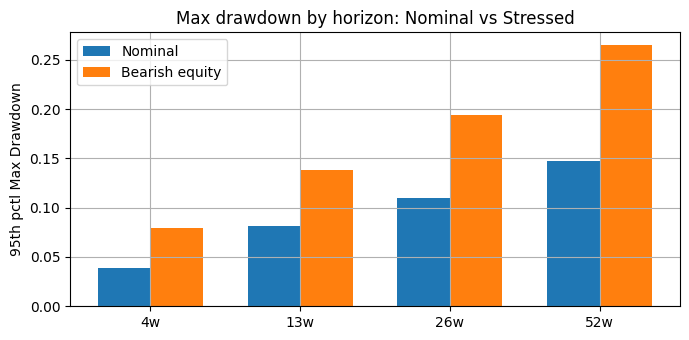

In [20]:
# --- Bar chart: 95th percentile max DD across horizons ---
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(dd_horizons))
w_bar = 0.35
ax.bar(x - w_bar/2, dd_nom_df["max_dd_95"].values,
       w_bar, label="Nominal")
ax.bar(x + w_bar/2, dd_stress_df["max_dd_95"].values,
       w_bar, label="Bearish equity")
ax.set_xticks(x)
ax.set_xticklabels([f"{h}w" for h in dd_horizons])
ax.set_ylabel("95th pctl Max Drawdown")
ax.set_title("Max drawdown by horizon: Nominal vs Stressed")
ax.legend(); plt.tight_layout(); plt.show()

In [21]:
# --- Simulate 1-year paths for drawdown histograms ---
paths_nom_1y = simulate_paths(
    log_returns.values, horizon=52, n_paths=2000, seed=42,
)
paths_str_1y = simulate_paths(
    log_returns.values, horizon=52, n_paths=2000,
    p=q_bear, seed=42,
)
def _max_dd(paths, w):
    wealth = np.exp(paths @ w)
    peak = np.maximum.accumulate(wealth, axis=1)
    dd = (peak - wealth) / np.where(peak > 0, peak, 1)
    return dd.max(axis=1)

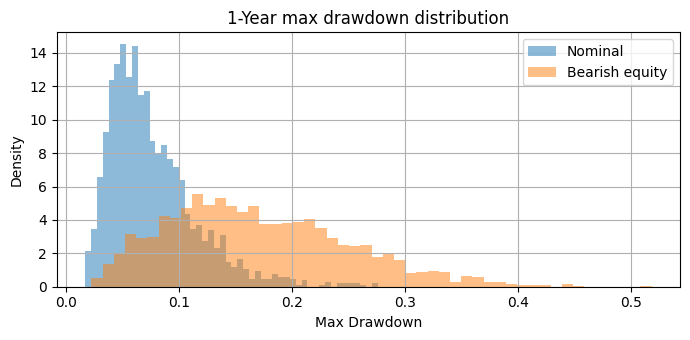

In [22]:
# --- Histogram: 1-year max drawdown distribution ---
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(_max_dd(paths_nom_1y, w_arr), bins=50,
        alpha=0.5, label="Nominal", density=True)
ax.hist(_max_dd(paths_str_1y, w_arr), bins=50,
        alpha=0.5, label="Bearish equity", density=True)
ax.set(xlabel="Max Drawdown", ylabel="Density",
       title="1-Year max drawdown distribution")
ax.legend(); plt.tight_layout(); plt.show()

---
## Section 6 -- Multi-Portfolio Comparison

We compare the tangency portfolio against the minimum-risk portfolio and
an equal-weight (1/N) allocation across scenarios and horizons.

In [23]:
# --- Build alternative portfolios ---
w_minrisk, _, _ = frontier.min_risk()
w_equal = pd.Series(
    1.0 / len(ASSETS), index=ASSETS, name="Equal Weight",
)
portfolios = {
    "Tangency": w_tangency.values,
    "Min-Risk": w_minrisk.values,
    "Equal-Weight": w_equal.values,
}
print("Portfolio weights:")
pd.DataFrame(portfolios, index=ASSETS).round(3)

Portfolio weights:


,Tangency,Min-Risk,Equal-Weight
DBC,0.000,0.168,0.25
GLD,0.334,0.105,0.25
SPY,0.403,0.237,0.25
TLT,0.263,0.490,0.25


In [24]:
# --- Horizon + drawdown for each portfolio x scenario ---
combo_rows = []
for pname, w in portfolios.items():
    for sname, q in scenarios.items():
        hr = horizon_report(w, log_returns.values, horizons=[13, 52],
                            n_simulations=3000, p=q, confidence=0.95, seed=42)
        dd = drawdown_quantile(w, log_returns.values, horizon=52,
                               confidence=0.95, n_paths=1000, p=q, seed=42)
        for hl in hr.index:
            row = {"portfolio": pname, "scenario": sname,
                   "horizon": hl, "max_dd_95": dd["max_dd_95"]}
            row.update(hr.loc[hl].to_dict())
            combo_rows.append(row)
combo_df = pd.DataFrame(combo_rows)

In [25]:
# --- Summary table: portfolio x scenario x horizon ---
summary = combo_df.pivot_table(
    index=["portfolio", "scenario"],
    columns="horizon",
    values=["CVaR95", "max_dd_95"],
)
print("Multi-portfolio stress summary (CVaR95 + DD95):")
summary.round(4)

Multi-portfolio stress summary (CVaR95 + DD95):


CVaR95         max_dd_95        
horizon                          1y      3m        1y      3m
portfolio    scenario                                        
Equal-Weight Bearish equity  0.2866  0.1597    0.2759  0.2759
             Corr breakdown  0.2488  0.1432    0.2546  0.2546
             Nominal         0.1375  0.0864    0.1512  0.1512
             Rising rates    0.1562  0.0959    0.1756  0.1756
Min-Risk     Bearish equity  0.2504  0.1405    0.2307  0.2307
             Corr breakdown  0.2459  0.1455    0.2415  0.2415
             Nominal         0.1182  0.0778    0.1310  0.1310
             Rising rates    0.1818  0.0992    0.1798  0.1798
Tangency     Bearish equity  0.2862  0.1595    0.2667  0.2667
             Corr breakdown  0.2372  0.1437    0.2452  0.2452
             Nominal         0.1168  0.0846    0.1429  0.1429
             Rising rates    0.1485  0.0927    0.1694  0.1694

---
## Section 7 -- Summary Dashboard

A single table bringing together the key findings.

In [26]:
# --- Final dashboard DataFrame ---
dash = combo_df[
    combo_df["horizon"] == "1y"
].pivot_table(
    index="portfolio",
    columns="scenario",
    values=["mean", "CVaR95", "max_dd_95"],
)
print("=== 1-Year Dashboard ===")
dash.round(4)

=== 1-Year Dashboard ===


CVaR95                                      \
scenario     Bearish equity Corr breakdown Nominal Rising rates   
portfolio                                                         
Equal-Weight         0.2866         0.2488  0.1375       0.1562   
Min-Risk             0.2504         0.2459  0.1182       0.1818   
Tangency             0.2862         0.2372  0.1168       0.1485   

                  max_dd_95                                      \
scenario     Bearish equity Corr breakdown Nominal Rising rates   
portfolio                                                         
Equal-Weight         0.2759         0.2546  0.1512       0.1756   
Min-Risk             0.2307         0.2415  0.1310       0.1798   
Tangency             0.2667         0.2452  0.1429       0.1694   

                       mean                                      
scenario     Bearish equity Corr breakdown Nominal Rising rates  
portfolio                                                        
Equal-Weight        -0.0807         0.0245  0.0753       0.0539  
Min-Risk            -0.0472         0.0113  0.0609      -0.0015  
Tangency            -0.0740         0.0495  0.0974       0.0648

### Key Takeaways

1. **Risk scales non-linearly**: CVaR at 1-year is substantially larger
   than 4x the 3-month figure due to compounding and fat tails.

2. **Bearish equity stress** significantly increases CVaR and drawdowns
   for equity-heavy portfolios, while the min-risk allocation is more
   resilient.

3. **Correlation breakdown** (positive SPY-TLT) undermines the
   diversification benefit of bonds, widening the drawdown distribution.

4. **Shock + mean reversion** shows that even with a recovery phase,
   the median terminal wealth may remain below the starting level for
   concentrated equity portfolios.

5. **Equal-weight** provides a simple but effective hedge across
   scenarios, sitting between tangency and min-risk on most metrics.

6. **Rising rates** stress primarily hits bond-heavy allocations;
   a pure equity portfolio is indirectly affected through correlation
   channels.

These results illustrate why multi-scenario, multi-horizon stress
testing is essential for robust portfolio construction.